In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [43]:
def f(x):
    return 3 * x ** 2 - 4 * x + 5

In [44]:
f(3.0)

20.0

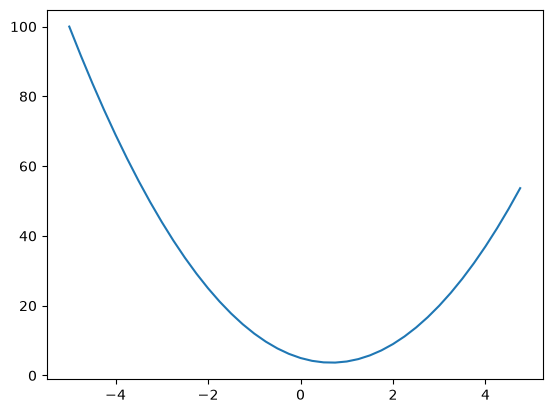

In [45]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [46]:
h = 0.0000001
x = 3.0
(f(x + h) - f(x))/h

14.000000305713911

In [47]:
h = 0.00000000000000001
x = 3.0
(f(x + h) - f(x))/h

0.0

In [48]:
h = 0.000001
x = -3.0
(f(x + h) - f(x))/h

-21.999997002808414

In [49]:
h = 0.0001
x = 2/3
(f(x + h) - f(x))/h

0.0002999999981767587

In [50]:
# Let's get more complex
a = 2.0
b = -3.0
c = 10.0
d= a * b + c
print(d)

4.0


In [51]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1= a * b + c
a += h
d2 = a * b + c

print('d1:', d1)
print('d2:', d2)
print('slope:', (d2 - d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


In [52]:
class Value:

    def __init__(self, data, _children=(), _op=(), label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh" )
        return out
 
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
print(a + b)
print(a * b)
print(e + c)
print(a.__mul__(b).__add__(c))
print(d) 
print(d._prev, d._op)
print(L)

Value(data=-1.0)
Value(data=-6.0)
Value(data=4.0)
Value(data=4.0)
Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)} +
Value(data=-8.0)


In [53]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

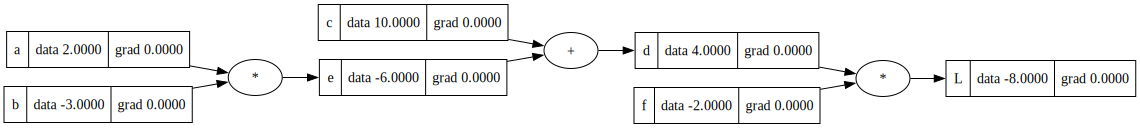

In [54]:
draw_dot(L)

In [55]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0

# dL / dc = (dL / dd) * (dd / dc)
# "+" operation means route in backpropogation, because dd / dc = 1 = dd / de
# So c.grad = -2.0 * 1 = -2.0
# The gradient of e is the same as above procedure
c.grad = -2.0   # Beacause of the chain rule, the gradient of c is the same as the gradient of d, which is -2.0.
e.grad = -2.0

# dL / da = (dL / de) * (de / da) = -2.0 * -3.0 = 6.0
a.grad = 6.0
b.grad = -4.0

In [56]:
# 0.01 is the learning rate.
# Only leaf nodes would be updated to look for a larger L. Because only leaf nodes
# are inputs we can control, other nodes are derived by leaf nodes.
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


In [57]:
def lol():
    
    h = 0.001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    d.data += h
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L2 = L.data

    print((L2 - L1) / h)

lol()

-2.000000000000668


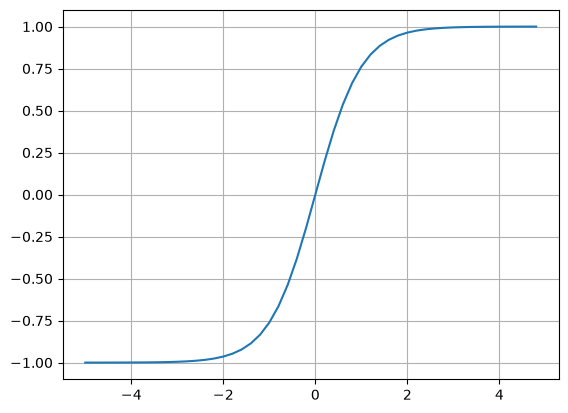

In [58]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

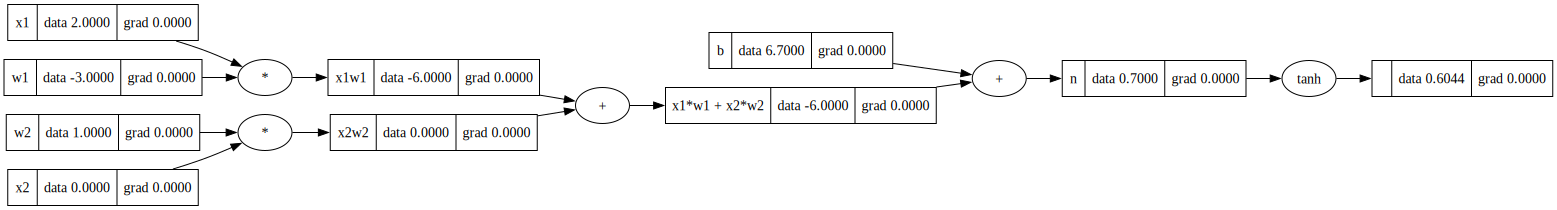

In [59]:
# inputs
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weights
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.7, label="b")
# w1 * x1 + w2 * x2 + b
x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2" # Make the figure more clear by adding a labeled node.
n = x1w1x2w2 + b; n.label = "n"
# Hyperbolic function as activation function tanh()
o = n.tanh()
draw_dot(o)